In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

import sys
sys.path.append('..')

import PyESRSTM

# Time Propagation

This tutorial goes beyond the steady-state ESR calculation and shows how to propagate the quantum dot density matrix in time.

In the previous example we solved the master equation in steady state. That is useful when we only care about the long-time average signal. However, many interesting phenomena require information about the transient dynamics:

- Rabi oscillations under resonant driving
- Relaxation into a new steady state after a pulse
- Time-dependent driving with arbitrary modulation
- Response to non-stationary or multi-frequency drives
- Spin dynamics starting from a chosen initial state

We begin by defining a driven quantum dot with a time-dependent tunnel coupling, and then evolve the density matrix in time. The goal is to observe how the quantum state evolves from a chosen initial condition toward the driven steady state.

Hermiticity check passed!


/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


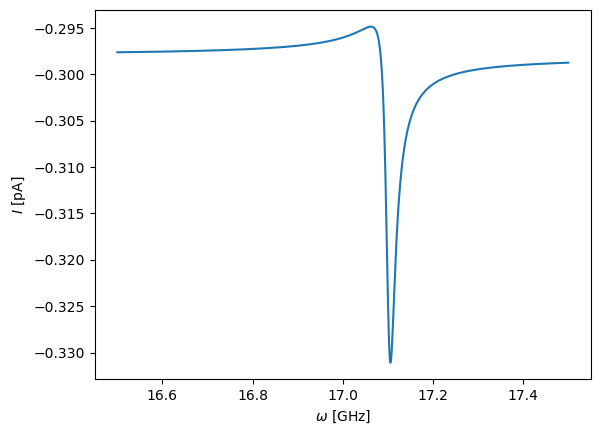

In [2]:
A = .5 

dot = PyESRSTM.QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=.5)

freq_long_time = np.linspace(16.5, 17.5, 1000)
I_long_time = PyESRSTM.ESR.ESR(Left, Right, dot, freq_long_time, NFL=1)
# the returned signal is in the shape (len(freq), 2*NFL+1)

plt.plot(freq_long_time, I_long_time[:, 2])
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()


Next we examine the time evolution of the system near resonance. We choose a driving frequency of $\omega = 17.1$ GHz, close to the ESR transition, and prepare the system in the ground state.

The `propagate_density` function takes the initial density matrix, total propagation time, the tunneling rates, energy differences `dot.Delta`, and the driving frequency as inputs. Internally, it integrates the quantum master equation in time using a solver from SciPy.

It is worth noting that the units are mixed: some quantities are in atomic units inside the model, while the user-defined frequency and time are typically given in GHz and ns. This is handled internally by the library, but it is important to keep track of the units when interpreting the output.

In [3]:
freq = 17.1

GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)

GL = GLplus + GLminus
GR = GRplus + GRminus
GC = GLplus - GLminus

In [4]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1

kwargs = {'max_step': 0.005, 'method': 'RK45'}
time, rhot = PyESRSTM.propagate_density(rho0, 700, GL, GR, dot.Delta, frequency=freq, kwargs=kwargs)

Below we plot the time evolution of the spin components and the current. We compute the spin observables from the time-dependent density matrix:

- $S_x = \frac{1}{2}\mathrm{Re}(\rho_{01} + \rho_{10})$
- $S_y = \frac{1}{2}\mathrm{Im}(\rho_{01} - \rho_{10})$
- $S_z = \frac{1}{2}\mathrm{Re}(\rho_{11} - \rho_{00})$

We then compute the current using `current_in_time`, which integrates the instantaneous current from the evolving density matrix. Finally, we fit the Rabi oscillations to extract the amplitude, frequency, and decay time.

Rabi oscillation: 
  A = 0.496
  Omega = 75.811 [MHz]
  T2 = 36.799 [ns]
  QF = 0.444
Average current after 500 ns: -1.389 [pA]


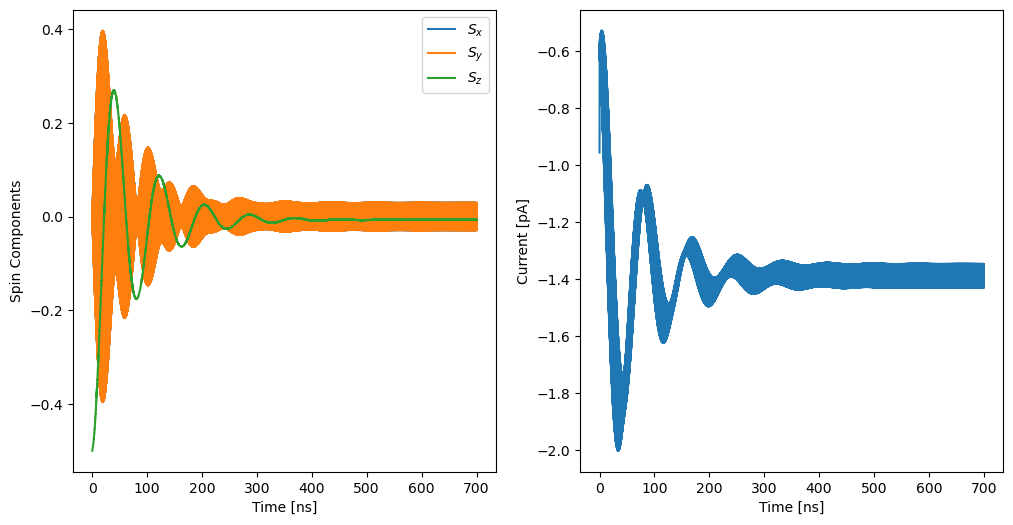

In [5]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))
ax = ax.flatten()


Sx = 1/2*np.real(rhot[:, 0, 1] + rhot[:, 1, 0])
Sy = 1/2*np.real(1j*(rhot[:, 0,1] - rhot[:, 1,0]))
Sz = 1/2*np.real(rhot[:,1, 1] - rhot[:,0, 0])

I = PyESRSTM.current_in_time(time, rhot, GC, 17.1)


def rabi_oscillation(x, A, omega, T2):
    return A * np.exp(-x/(2*T2)) * np.cos(omega*x)

popt, pcov = curve_fit(rabi_oscillation, time, Sz)

print(f"Rabi oscillation: \n  A = {np.round(np.abs(popt[0]),3)}\n  Omega = {np.round(1000*np.abs(popt[1]),3)} [MHz]\n  T2 = {np.round(popt[2],3)} [ns]\n  QF = {np.round(popt[2]*np.abs(popt[1])/(2*np.pi),3)}")

average_current = np.mean(I[time > 500])
print(f"Average current after 500 ns: {np.round(average_current,3)} [pA]")

ax[0].plot(time, Sx, label=r'$S_x$')
ax[0].plot(time, Sy, label=r'$S_y$')
ax[0].plot(time, Sz, label=r'$S_z$')
ax[1].plot(time, I,)

ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Spin Components')
ax[0].legend()
ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Current [pA]')

plt.show()


Likewise, we can initialize the system in a charged state and examine the population lifetime $T_{pop}$. This is a useful way to quantify how quickly the system relaxes from an excited or occupied configuration into a more stable distribution.

The code below prepares the system in an excited state and then tracks the time evolution of the population. The decay is fitted to an exponential form $P(t) = e^{-t/T_{pop}}$ to extract the relaxation time.

Tpopulation = 0.10735274875171275 [ns]


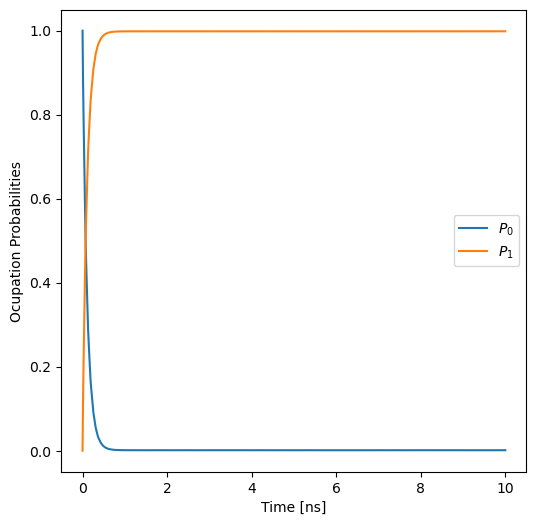

In [6]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[2, 2] = 1
time, rhot = PyESRSTM.propagate_density( rho0, 10, GL, GR, dot.Delta, frequency=17.1, kwargs=kwargs)

def fit_decay(x, T1):
    return np.exp(-x/T1)

popt, pcov = curve_fit(fit_decay, time, np.real(rhot[:, 2,2]))

print(f"Tpopulation = {popt[0]} [ns]") 

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(time, np.real(rhot[:, 2,2]), label=r'$P_{0}$')
ax.plot(time, np.real(rhot[:, 0,0]+rhot[:, 1,1]), label=r'$P_{1}$')


ax.set_xlabel('Time [ns]')
ax.set_ylabel('Ocupation Probabilities')
ax.legend()
plt.show()

### Inputting Time-Dependent Driving

The previous examples used a time-dependent tunneling rate with a single driving frequency. PyESRSTM allows three different ways to specify time dependence.

1. Full Fourier representation
   - Pass the full Fourier components of the rates as a tensor with shape `(Ndim, Ndim, Ndim, Ndim, NF)`.
   - This is convenient when the drive is described as a harmonic expansion.

2. Multi-frequency adrive specification
   - Pass only the zeroth Fourier component and separately provide a list of driving frequencies and amplitudes.
   - This is useful for describing a sum of harmonics, e.g. $\Gamma(t) = \Gamma_0 \sum_n A_n \cos(\omega_n t)$.

3. User-defined driving function
   - Provide `drho_function` or a custom time-dependent generator for the Liouvillian.
   - This gives maximum flexibility when the drive is not a simple harmonic signal or when the time dependence is custom.

The examples below implement the same simple cosine modulation in all three ways so that we can compare their behavior and numerical cost.

In [7]:
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=0)

GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)


GL = GLplus + GLminus
GR = GRplus + GRminus

GL[:,:,:,:,0] = GL[:,:,:,:,1] * A
GL[:,:,:,:,2] = GL[:,:,:,:,1] * A

rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1


In [8]:
from time import time as t

t1 = t()
# here we use the full rates including their higher fourier components, 
time_four, rhot_four = PyESRSTM.propagate_density(rho0, 70, GL, GR, dot.Delta, frequency=freq, kwargs=kwargs)
t2 = t()
print(f"Time for full fourier propagation: {np.round(t2-t1,3)} [s]")

# for adrinving the frequncy most be an array now, and we only care about the the 0th fourier component of GL 
t1 = t()
# here we only inpu the 0th fourier components, hence the 1:2 slicing of the last axis of GL
# the driving amplitude is set by the adrive keyword
time_A, rhot_A = PyESRSTM.propagate_density(rho0, 70, GL[:,:,:,:,1:2], GR, dot.Delta, frequency=np.array([freq]), adrive=np.array([2*A]), kwargs=kwargs)
t2 = t()
print(f"Time for adrive propagation: {np.round(t2-t1,3)} [s]")

# The predifined driving function is below
# !!! Mind the unit conversion of frequency, time input will be in atomic units.
Ndim = dot.Nstate
# the slicing of ML,MR is there becuase the last axis of GL has the fourier components, and we only need the 0th component for this specific driving function
ML = PyESRSTM.QME_matrix_propagator(GL[:,:,:,:,1:2], np.zeros_like(dot.Delta))[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)
MR = PyESRSTM.QME_matrix_propagator(GR, dot.Delta)[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)
f= freq * 2*np.pi * PyESRSTM.time_unit 

def single_step_adrive_add_hoc(t, rho):
    phase = 1 + 2*A*np.cos(f * t)
    M_t = MR + ML * phase
    drho = M_t @ rho
    
    return drho

t1 = t()
time_hand, rhot_hand = PyESRSTM.propagate_density(rho0, 70, drho_function=single_step_adrive_add_hoc, kwargs=kwargs)
t2 = t()
print(f"Time for adrive propagation with hand coded driving function: {np.round(t2-t1,3)} [s]")

Time for full fourier propagation: 3.04 [s]
Time for adrive propagation: 2.203 [s]
Time for adrive propagation with hand coded driving function: 1.566 [s]


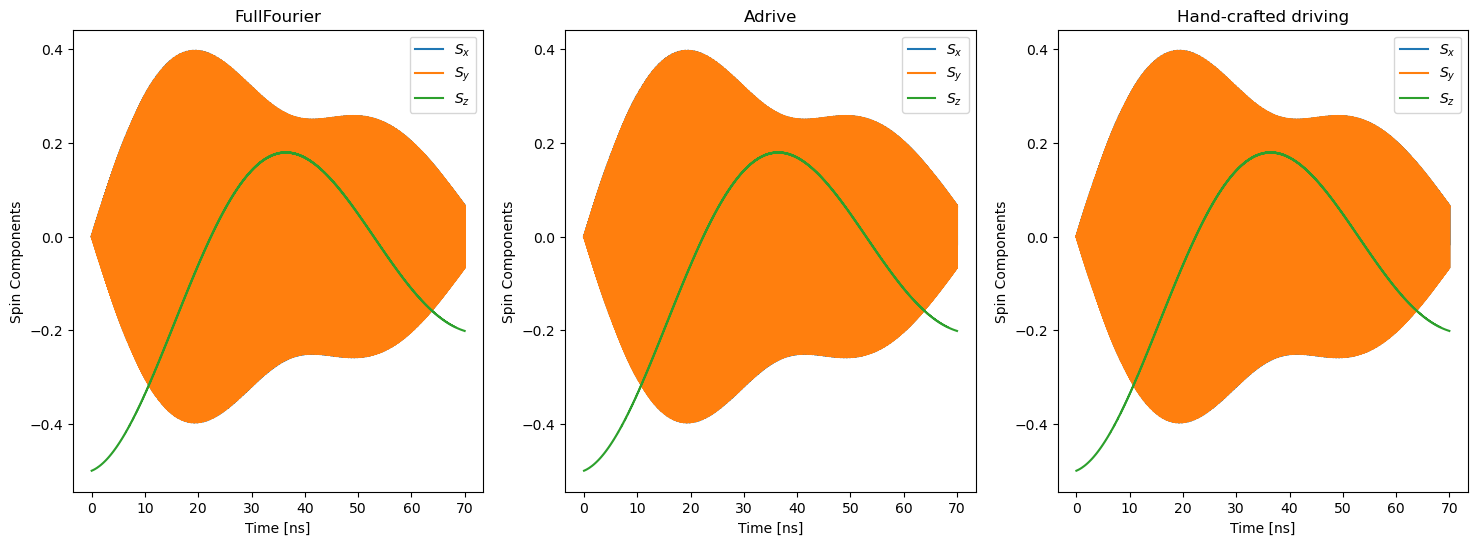

In [9]:
fig, ax = plt.subplots(1,3 , figsize=(18,6))
ax = ax.flatten()

Sx_four = 1/2*np.real(rhot_four[:, 0, 1] + rhot_four[:, 1, 0])
Sy_four = 1/2*np.real(1j*(rhot_four[:, 0,1] - rhot_four[:, 1,0]))
Sz_four = 1/2*np.real(rhot_four[:,1, 1] - rhot_four[:,0, 0])

ax[0].plot(time_four, Sx_four, label=r'$S_x$')
ax[0].plot(time_four, Sy_four, label=r'$S_y$')
ax[0].plot(time_four, Sz_four, label=r'$S_z$')
ax[0].set_title('FullFourier')

Sx_A = 1/2*np.real(rhot_A[:, 0, 1] + rhot_A[:, 1, 0])
Sy_A = 1/2*np.real(1j*(rhot_A[:, 0,1] - rhot_A[:, 1,0]))
Sz_A = 1/2*np.real(rhot_A[:,1, 1] - rhot_A[:,0, 0])

ax[1].plot(time_A, Sx_A, label=r'$S_x$')
ax[1].plot(time_A, Sy_A, label=r'$S_y$')
ax[1].plot(time_A, Sz_A, label=r'$S_z$')
ax[1].set_title('Adrive')


Sx_hand = 1/2*np.real(rhot_hand[:, 0, 1] + rhot_hand[:, 1, 0])
Sy_hand = 1/2*np.real(1j*(rhot_hand[:, 0,1] - rhot_hand[:, 1,0]))
Sz_hand = 1/2*np.real(rhot_hand[:,1, 1] - rhot_hand[:,0, 0])

ax[2].plot(time_hand, Sx_hand, label=r'$S_x$')
ax[2].plot(time_hand, Sy_hand, label=r'$S_y$')
ax[2].plot(time_hand, Sz_hand, label=r'$S_z$')
ax[2].set_title('Hand-crafted driving')

for a in ax:
    a.set_xlabel('Time [ns]')
    a.set_ylabel('Spin Components')
    a.legend() 

plt.show()

Likewise, there are three equivalent ways to specify how current is read out during time propagation. The choice depends on whether the drive is given as Fourier components, as an `adrive` field, or as a custom time-dependent generator for the current operator.

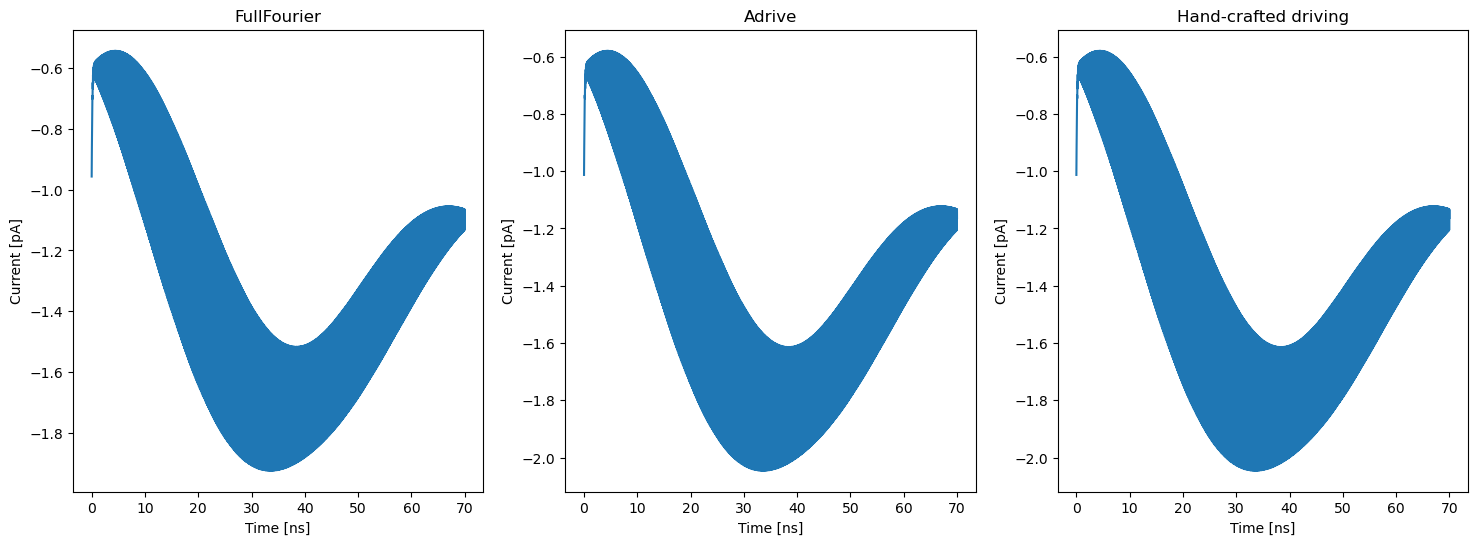

In [10]:
I_four = PyESRSTM.current_in_time(time_four, rhot_four, GC, frequency=freq)
I_A = PyESRSTM.current_in_time(time_A, rhot_A, GC[:, :, :, :, 1:2], frequency=np.array([freq]), adrive=np.array([2*A]))

def GC_adrive_add_hoc(t):
    phase = 1 + 2*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    return np.tensordot(phase[np.newaxis], GC[:, :, :, :, 1:2], axes=([0], [-1]))

I_hand = PyESRSTM.current_in_time(time_hand, rhot_hand, Gt_function=GC_adrive_add_hoc)

fig, ax = plt.subplots(1,3 , figsize=(18,6))

ax[0].plot(time_four, I_four)
ax[0].set_title('FullFourier')
ax[1].plot(time_A, I_A)
ax[1].set_title('Adrive')
ax[2].plot(time_hand, I_hand)
ax[2].set_title('Hand-crafted driving')

for a in ax:
    a.set_xlabel('Time [ns]')
    a.set_ylabel('Current [pA]')

plt.show()

### Multiple Frequencies

Using the `Adrive` approach, we can also study the response to a drive containing two unrelated frequencies. For a spin-1/2 impurity, this often does not create qualitatively new physics beyond the resonant component, but it is a useful demonstration of how the method handles multitone driving.

The code below compares a single-frequency drive with a double-frequency drive, both with the same total amplitude. A key point is that heterodyne-like responses are only expected when the frequency components beat together in a way that mixes with a resonant transition. For the simple spin-1/2 case, the response remains essentially governed by the resonant mode.

In [11]:
time_single, rhot_single = PyESRSTM.propagate_density(rho0, 300, GL[:,:,:,:,1:2], GR, dot.Delta, frequency=np.array([freq]), adrive=np.array([2*A]), kwargs=kwargs)
time_double, rhot_double = PyESRSTM.propagate_density(rho0, 300, GL[:,:,:,:,1:2], GR, dot.Delta, frequency=np.array([freq, freq+.5]), adrive=np.array([2*A,A]), kwargs=kwargs)

I_single = PyESRSTM.current_in_time(time_single, rhot_single, GC[:, :, :, :, 1:2], frequency=np.array([freq]), adrive=np.array([2*A]))
I_double = PyESRSTM.current_in_time(time_double, rhot_double, GC[:, :, :, :, 1:2], frequency=np.array([freq, freq+.5]), adrive=np.array([2*A,A]))

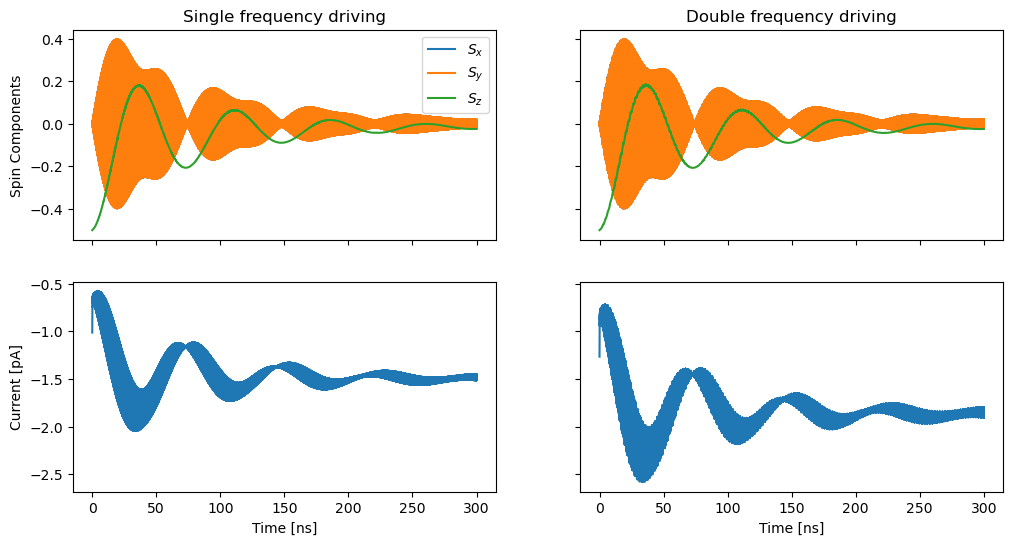

In [12]:
fig, ax = plt.subplots(2,2 , figsize=(12,6), sharex=True, sharey='row')
ax = ax.flatten()

Sx_single = 1/2*np.real(rhot_single[:, 0, 1] + rhot_single[:, 1, 0])
Sy_single = 1/2*np.real(1j*(rhot_single[:, 0,1] - rhot_single[:, 1,0]))
Sz_single = 1/2*np.real(rhot_single[:,1, 1] - rhot_single[:,0, 0])

ax[0].plot(time_single, Sx_single, label=r'$S_x$')
ax[0].plot(time_single, Sy_single, label=r'$S_y$')
ax[0].plot(time_single, Sz_single, label=r'$S_z$')

Sx_double = 1/2*np.real(rhot_double[:, 0, 1] + rhot_double[:, 1, 0])
Sy_double = 1/2*np.real(1j*(rhot_double[:, 0,1] - rhot_double[:, 1,0]))
Sz_double = 1/2*np.real(rhot_double[:,1, 1] - rhot_double[:,0, 0])

ax[1].plot(time_double, Sx_double, label=r'$S_x$')
ax[1].plot(time_double, Sy_double, label=r'$S_y$')
ax[1].plot(time_double, Sz_double, label=r'$S_z$')


ax[2].plot(time_single, I_single)
ax[3].plot(time_double, I_double)

ax[2].set_xlabel('Time [ns]')
ax[3].set_xlabel('Time [ns]')

ax[0].set_ylabel('Spin Components')
ax[2].set_ylabel('Current [pA]')

ax[0].legend()
ax[0].set_title('Single frequency driving')
ax[1].set_title('Double frequency driving')
plt.show()


The plot on the right seems to suggest that the response remains concentrated near resonance, even when the system is driven at two frequencies. This is consistent with the idea that resonance is selected by the spin transition itself, while the additional frequency component mainly contributes a weak modulation or mixing term.

This behavior is worth checking carefully—especially if one is interested in heterodyne detection or nonlinear mixing phenomena. In a more complex system, additional frequencies can give rise to richer dynamics, but for a simple spin-1/2 system the resonance still dominates the response.

### Pulsing

Using an ad hoc time-dependent drive, we can create pulses. In the example below, the driving amplitude is increased in steps every 50 ns and then switched off after 200 ns.

This is a simple way to model:
- excitation pulses
- pulsed ESR experiments
- controlled spin preparation and readout
- transient response to a time-varying drive

By changing the pulse envelope and amplitude, one can study a wide range of non-equilibrium protocols.

In [13]:
ML = PyESRSTM.QME_matrix_propagator(GL[:,:,:,:,1:2], np.zeros_like(dot.Delta))[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)
MR = PyESRSTM.QME_matrix_propagator(GR, dot.Delta)[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)

def single_step_adrive_add_hoc(t, rho):
    phase = 1 
    if t < 50/PyESRSTM.time_unit:
        phase += A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 100/PyESRSTM.time_unit:
        phase += 2*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 150/PyESRSTM.time_unit:
        phase += 4*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 200/PyESRSTM.time_unit:
        phase += 6*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)  
        
    M_t = MR + ML * phase
    drho = M_t @ rho

    return drho#.ravel()

def GC_adrive_add_hoc(t):
    phase = np.ones_like(t)
    t_ns = t * PyESRSTM.time_unit
    i0_50 = (t_ns < 50)
    i50_100 = (t_ns >= 50) & (t_ns < 100)
    i100_150 = (t_ns >= 100) & (t_ns < 150)
    i150_200 = (t_ns >= 150) & (t_ns < 200)
    phase[i0_50] += A*np.cos(freq * t[i0_50] * 2 * np.pi*PyESRSTM.time_unit)
    phase[i50_100] += 2*A*np.cos(freq * t[i50_100] * 2 * np.pi*PyESRSTM.time_unit)
    phase[i100_150] += 4*A*np.cos(freq * t[i100_150] * 2 * np.pi*PyESRSTM.time_unit)
    phase[i150_200] += 6*A*np.cos(freq * t[i150_200] * 2 * np.pi*PyESRSTM.time_unit)
    return np.tensordot(phase[np.newaxis], GC[:, :, :, :, 1:2], axes=([0], [-1]))

time_pulse, rhot_pulse = PyESRSTM.propagate_density(rho0, 300,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)
I_pulse = PyESRSTM.current_in_time(time_pulse, rhot_pulse, Gt_function=GC_adrive_add_hoc) 

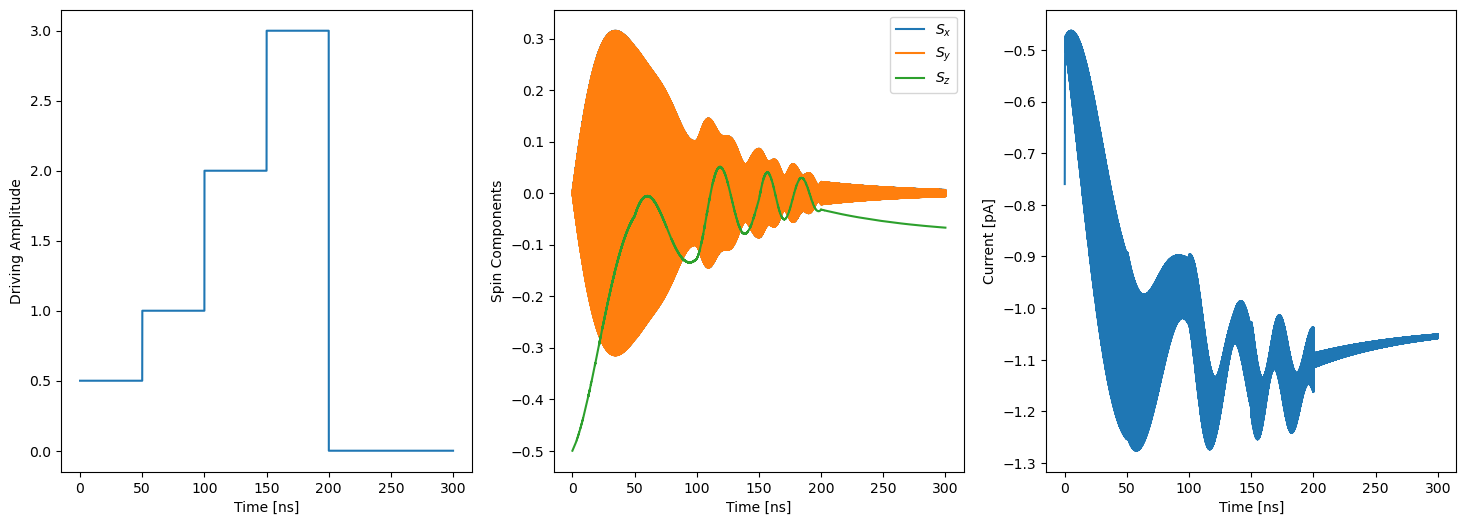

In [14]:
fig, ax = plt.subplots(1,3 , figsize=(18,6))

Sx_pulse = 1/2*np.real(rhot_pulse[:, 0, 1] + rhot_pulse[:, 1, 0])   
Sy_pulse = 1/2*np.real(1j*(rhot_pulse[:, 0,1] - rhot_pulse[:, 1,0]))
Sz_pulse = 1/2*np.real(rhot_pulse[:,1, 1] - rhot_pulse[:,0, 0])


ax[1].plot(time_pulse, Sx_pulse, label=r'$S_x$')  
ax[1].plot(time_pulse, Sy_pulse, label=r'$S_y$')
ax[1].plot(time_pulse, Sz_pulse, label=r'$S_z$')

A_pulse = np.zeros_like(time_pulse)
A_pulse[time_pulse < 50] = A
A_pulse[(time_pulse >= 50) & (time_pulse < 100)] = 2*A
A_pulse[(time_pulse >= 100) & (time_pulse < 150)] = 4*A
A_pulse[(time_pulse >= 150) & (time_pulse < 200)] = 6*A
A_pulse[time_pulse >= 200] = 0

ax[0].plot(time_pulse, A_pulse, label=r'$A(t)$')

ax[2].plot(time_pulse, I_pulse, label=r'$I(t)$')

ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Spin Components')
ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Driving Amplitude')
ax[2].set_xlabel('Time [ns]')
ax[2].set_ylabel('Current [pA]')
ax[1].legend()

plt.show()